# Step 3: Model Definitions and Prior Predictive Checks

We define two models and check their priors before seeing data.

| Model | Description | Pooling |
|-------|-------------|---------|
| **Empirical** | MLE per developer: `total_count / total_exposure` | None — each developer fully independent |
| **m1** | Intercepts for designation, team, developer — σ fixed | No pooling — groups don't share information |
| **m2** | Crossed hierarchy: org → designation + team → developer — σ estimated | Partial pooling — groups share information |

**Notation used throughout:**
- `d` = developer index (0 to 249)
- `t` = month index (1 to 6)
- `desig[d]` = designation of developer d
- `team[d]` = team of developer d

**Prior predictive check**: sample from priors (ignore observed data) and ask — do the implied counts make sense?

In [7]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy import special

rng = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

DESIGNATIONS = ['aSDE', 'SDE-1', 'SDE-2', 'SDE-3', 'SDE-4']
N_TEAMS      = 10
MU_ORG       = np.log(8)

df = pd.read_csv('../../data/pr_simulated.csv')
print(f"Loaded {len(df)} rows")
df.head(4)

Loaded 1896 rows


,developer_id,month,designation,desig_id,team,team_id,tier,true_lam,exposure,pr_count
0,0,1,aSDE,0,Team-1,0,balanced,10.316876,1.0,13
1,0,2,aSDE,0,Team-1,0,balanced,10.316876,1.0,6
2,0,3,aSDE,0,Team-1,0,balanced,10.316876,1.0,12
3,0,4,aSDE,0,Team-1,0,balanced,10.316876,1.0,11


## Prepare Index Arrays

PyMC needs integer index arrays to index into parameter vectors.

In [8]:
# Integer indices (one per row)
dev_ids   = df['developer_id'].values
desig_ids = df['desig_id'].values
team_ids  = df['team_id'].values
pr_obs    = df['pr_count'].values
exposure  = df['exposure'].values   # all 1.0 for now
log_exp   = np.log(exposure)        # offset term (log scale)

N_DEVS    = df['developer_id'].nunique()
N_DESIG   = len(DESIGNATIONS)
N_TEAMS   = df['team_id'].nunique()

# Coords for labelled dimensions in PyMC
coords = {
    'developer'   : np.arange(N_DEVS),
    'designation' : DESIGNATIONS,
    'team'        : [f'Team-{i+1}' for i in range(N_TEAMS)],
    'obs_id'      : np.arange(len(df)),
}

print(f"N_DEVS={N_DEVS}, N_DESIG={N_DESIG}, N_TEAMS={N_TEAMS}, N_OBS={len(df)}")

N_DEVS=316, N_DESIG=5, N_TEAMS=15, N_OBS=1896


## Empirical Estimates (MLE)

The simplest possible estimate: total PRs divided by total exposure per developer.
No priors, no pooling — just raw data.

```
λ̂_dev = Σ pr_count / Σ exposure
```

This is the **maximum likelihood estimate** for a Poisson rate.
It will be our baseline to compare against model posteriors later.

Empirical estimate summary by designation:
               mean  median    std
designation                       
aSDE          7.889   7.167  3.637
SDE-1        12.376  11.500  6.574
SDE-2        11.320  10.667  4.256
SDE-3         6.167   5.417  3.488
SDE-4         4.294   3.833  2.136


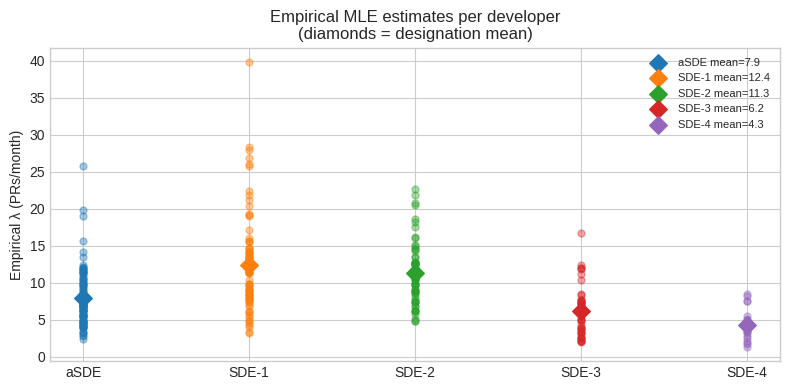

In [9]:
def empirical_estimates(data):
    """
    Compute MLE Poisson rate per developer.
    Returns a DataFrame indexed by developer_id.
    """
    agg = (data.groupby(['developer_id', 'designation', 'team'])
               .agg(total_count=('pr_count', 'sum'),
                    total_exposure=('exposure', 'sum'))
               .reset_index())
    agg['empirical_lam'] = agg['total_count'] / agg['total_exposure']
    return agg

emp = empirical_estimates(df)

print("Empirical estimate summary by designation:")
print(emp.groupby('designation')['empirical_lam']
         .agg(['mean','median','std'])
         .reindex(DESIGNATIONS)
         .round(3))

fig, ax = plt.subplots(figsize=(8, 4))
for i, desig in enumerate(DESIGNATIONS):
    vals = emp[emp.designation == desig]['empirical_lam']
    ax.scatter([i]*len(vals), vals, alpha=0.4, color=f'C{i}', s=25)
    ax.scatter(i, vals.mean(), marker='D', s=80, color=f'C{i}', zorder=5,
               label=f'{desig} mean={vals.mean():.1f}')
ax.set_xticks(range(N_DESIG))
ax.set_xticklabels(DESIGNATIONS)
ax.set_ylabel("Empirical λ (PRs/month)")
ax.set_title("Empirical MLE estimates per developer\n(diamonds = designation mean)")
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## Model 1 — No Pooling

Each group (designation, team, developer) gets its own intercept, but **σ is fixed by us — not learned from data**. This is the key difference from m2.

```
pr_count_{d,t} ~ Poisson(λ_d × exposure_{d,t})

log(λ_d) = log(exposure_{d,t})
           + μ_org
           + α_desig[ desig[d] ]
           + α_team[  team[d]  ]
           + α_dev[   d        ]

where:
  d = developer (0–249)
  t = month     (1–6)
  desig[d], team[d] = group membership of developer d

μ_org       ~ Normal(log(8), 0.5)
α_desig     ~ Normal(0, 1)     ← σ = 1.0, FIXED — not learned from data
α_team      ~ Normal(0, 1)     ← σ = 1.0, FIXED — not learned from data
α_dev       ~ Normal(0, 1)     ← σ = 1.0, FIXED — not learned from data
```

**Why is this "no pooling"?**
Learning that Team-3 is productive tells us *nothing* about Team-7, because σ_team is hardcoded — it never adapts to the data. Each group is estimated in isolation with the same fixed prior width.

In m2, σ_team is *estimated* from all teams together, so teams inform each other through the shared hyperprior — that is partial pooling.

In [10]:
with pm.Model(coords=coords) as m1:
    # ── Grand mean ────────────────────────────────────────────────────
    mu_org = pm.Normal('mu_org', mu=np.log(8), sigma=0.5)

    # ── One intercept per group — σ is FIXED (not estimated) ──────────
    # This is what makes it "no pooling": groups don't share information
    alpha_desig = pm.Normal('alpha_desig', mu=0, sigma=1, dims='designation')
    alpha_team  = pm.Normal('alpha_team',  mu=0, sigma=1, dims='team')
    alpha_dev   = pm.Normal('alpha_dev',   mu=0, sigma=1, dims='developer')

    # ── Per-observation log(lambda) ────────────────────────────────────
    log_lam = (log_exp
               + mu_org
               + alpha_desig[desig_ids]
               + alpha_team[team_ids]
               + alpha_dev[dev_ids])
    lam = pm.Deterministic('lam', pm.math.exp(log_lam), dims='obs_id')

    obs = pm.Poisson('obs', mu=lam, observed=pr_obs, dims='obs_id')

print(m1.str_repr())

     mu_org ~ Normal(2.08, 0.5)
alpha_desig ~ Normal(0, 1)
 alpha_team ~ Normal(0, 1)
  alpha_dev ~ Normal(0, 1)
        lam ~ Deterministic(f(alpha_dev, alpha_team, alpha_desig, mu_org))
        obs ~ Poisson(lam)


## Model 2 — Crossed Hierarchy (Partial Pooling)

Same structure as m1, but now **sigma is estimated from data** — this is the key change that enables partial pooling.

---

### Why partial pooling works: the key insight

The model has three levels of deviation, each with a learned spread:

- **mu_org**: org-level mean — learned from all 1896 rows
- **gamma[team]**: team-specific deviation from org mean — one value per team, learned from that team's own data
- **sigma_team**: how much teams typically vary from org mean — one global value, learned from all 15 teams together

**Why gamma starts at 0:** gamma[team] is a deviation *relative to* mu_org, not an absolute rate. mu_org already captures the mean, so gamma just asks 'is this team above or below average?' Starting at 0 means 'no deviation assumed by default.'

**Why sigma_team is global (not per-team):** sigma_team answers the question 'how much do teams typically vary?' — that is an org-level property, not a team-level property. You need all 15 teams together to estimate it. A single team cannot tell you how much teams vary.

**How shrinkage happens:**
- Prior: `gamma[team] ~ Normal(0, sigma_team)` — start at zero, width controlled by sigma_team
- Each team's own data pulls `gamma[team]` away from 0
- How far it moves depends on how much data that team has:
  - Lots of data → posterior moves far from 0 (data wins)
  - Little data → posterior stays near 0 (prior wins → shrinkage toward org mean)

---

### Step 1: Centred parameterisation (intuitive form)

Start here to understand the structure. Each random effect is sampled directly:

```
mu_org      ~ Normal(log(8), 0.5)
sigma_desig ~ Exponential(1)
sigma_team  ~ Exponential(1)
sigma_dev   ~ Exponential(1)

delta[desig] ~ Normal(0, sigma_desig)   # designation deviation from org mean
gamma[team]  ~ Normal(0, sigma_team)    # team deviation from org mean
epsilon[dev] ~ Normal(0, sigma_dev)     # individual developer noise

log(lambda_d) = mu_org + delta[desig[d]] + gamma[team[d]] + epsilon[d]
```

This reads naturally: each team deviates from the org mean, with typical deviation sigma_team.

---

### Step 2: The funnel problem with centred form

When sigma_team is small (teams are very similar), the posterior of gamma becomes a very narrow funnel. MCMC takes tiny steps near the neck and gets stuck — this causes **divergences**.

```
sigma_team large:   gamma can range widely   → easy to sample
sigma_team small:   gamma squeezed near 0    → MCMC gets stuck
```

---

### Step 3: Non-centred reparameterisation (what the code uses)

Instead of sampling gamma directly, we separate the shape from the scale:

```
# Centred (problematic when sigma is small):
gamma[team] ~ Normal(0, sigma_team)

# Non-centred (what we use):
z_team[team] ~ Normal(0, 1)            # always standard normal — easy to sample
gamma[team]   = z_team[team] * sigma_team   # deterministic rescaling
```

Mathematically identical. But now MCMC samples `z_team` which has the same shape regardless of how small sigma_team is — no funnel, no divergences.

---

### Full non-centred model (what the code implements)

```
pr_count_{d,t} ~ Poisson(lambda_d * exposure_{d,t})

log(lambda_d) = log(exposure_{d,t})
              + mu_org
              + delta[ desig[d] ]
              + gamma[ team[d]  ]
              + alpha[ d        ]

delta[desig] = z_desig[desig] * sigma_desig
gamma[team]  = z_team[team]   * sigma_team
alpha[dev]   = z_dev[dev]     * sigma_dev

z_desig, z_team, z_dev ~ Normal(0, 1)
mu_org      ~ Normal(log(8), 0.5)
sigma_desig ~ Exponential(1)       # ESTIMATED from all designations together
sigma_team  ~ Exponential(1)       # ESTIMATED from all teams together
sigma_dev   ~ Exponential(1)       # ESTIMATED from all developers together
```

**Crossed structure**: designation and team effects are independent. Each developer gets one offset from the designation array AND one offset from the team array — knowing a developer's team tells you nothing about their designation.


In [11]:
with pm.Model(coords=coords) as m2:
    # ── Hyperpriors ───────────────────────────────────────────────────
    mu_org      = pm.Normal('mu_org',     mu=np.log(8), sigma=0.5)
    sigma_desig = pm.Exponential('sigma_desig', lam=1)
    sigma_team  = pm.Exponential('sigma_team',  lam=1)
    sigma_dev   = pm.Exponential('sigma_dev',   lam=1)

    # ── Non-centred random effects ────────────────────────────────────
    z_desig = pm.Normal('z_desig', mu=0, sigma=1, dims='designation')
    z_team  = pm.Normal('z_team',  mu=0, sigma=1, dims='team')
    z_dev   = pm.Normal('z_dev',   mu=0, sigma=1, dims='developer')

    # ── Group offsets ─────────────────────────────────────────────────
    delta = pm.Deterministic('delta', z_desig * sigma_desig, dims='designation')
    gamma = pm.Deterministic('gamma', z_team  * sigma_team,  dims='team')

    # ── Per-developer intercept ───────────────────────────────────────
    mu_dev = mu_org + delta[desig_ids[::6]] + gamma[team_ids[::6]]  # one per dev
    alpha  = pm.Deterministic(
                'alpha',
                mu_dev + z_dev * sigma_dev,
                dims='developer')

    # ── Likelihood (one row per developer-month) ──────────────────────
    log_lam = log_exp[dev_ids] + alpha[dev_ids]
    lam     = pm.Deterministic('lam', pm.math.exp(log_lam), dims='obs_id')

    obs = pm.Poisson('obs', mu=lam, observed=pr_obs, dims='obs_id')

print(m2.str_repr())

     mu_org ~ Normal(2.08, 0.5)
sigma_desig ~ Exponential(f())
 sigma_team ~ Exponential(f())
  sigma_dev ~ Exponential(f())
    z_desig ~ Normal(0, 1)
     z_team ~ Normal(0, 1)
      z_dev ~ Normal(0, 1)
      delta ~ Deterministic(f(z_desig, sigma_desig))
      gamma ~ Deterministic(f(z_team, sigma_team))
      alpha ~ Deterministic(f(z_dev, sigma_dev, mu_org, z_team, sigma_team, z_desig, sigma_desig))
        lam ~ Deterministic(f(z_dev, sigma_dev, mu_org, z_team, sigma_team, z_desig, sigma_desig))
        obs ~ Poisson(lam)


## Model Simple — Per-Developer Rate (Minimal Hierarchy)

The simplest Bayesian model: one rate per developer, no designation or team effects.

```
pr_count_{d,t} ~ Poisson(lambda_d * exposure_{d,t})

log(lambda_d) = mu_org + z_dev[d] * sigma_dev

mu_org    ~ Normal(log(8), 0.5)   # org mean
sigma_dev ~ HalfNormal(0.5)       # how much developers vary
z_dev     ~ Normal(0, 1)          # per-developer effect (non-centred)
```

**Why this model is useful:**
- Simpler than m2 — no designation or team effects
- Still Bayesian — gives uncertainty intervals unlike pure MLE
- Side-by-side with m2: shows what the hierarchy adds
- Anomaly detection: if m2 estimate is very different from m_simple, the hierarchy (team/designation context) is pulling hard

**Key difference from m2:** sigma_dev is the only source of variation. All developer differences are attributed to individual noise — no separation into designation effect vs team effect vs individual noise.

In [ ]:
with pm.Model(coords=coords) as m_simple:
    # ── Org mean ─────────────────────────────────────────────────────
    mu_org    = pm.Normal('mu_org',    mu=np.log(8), sigma=0.5)
    sigma_dev = pm.HalfNormal('sigma_dev', sigma=0.5)

    # ZeroSumNormal anchors mu_org — prevents ridge between mu_org and z_dev
    z_dev  = pm.ZeroSumNormal('z_dev', sigma=1, dims='developer')
    alpha  = pm.Deterministic('alpha', mu_org + z_dev * sigma_dev,
                              dims='developer')

    # ── Likelihood ────────────────────────────────────────────────────
    log_lam = log_exp + alpha[dev_ids]
    lam     = pm.Deterministic('lam', pm.math.exp(log_lam), dims='obs_id')
    obs     = pm.Poisson('obs', mu=lam, observed=pr_obs, dims='obs_id')

print(m_simple.str_repr())

## Prior Predictive Check — m_simple

In [ ]:
with m_simple:
    prior_simple = pm.sample_prior_predictive(samples=500, random_seed=42)

prior_counts_simple = prior_simple.prior_predictive['obs'].values.flatten()
prior_lam_simple    = prior_simple.prior['lam'].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(prior_counts_simple,
        bins=range(0, min(int(prior_counts_simple.max())+2, 100)),
        color='C2', alpha=0.7, edgecolor='white', density=True)
ax.axvline(8, color='red', linestyle='--', lw=2, label='Expected mean (8/mo)')
ax.set_xlabel('Simulated monthly PR count')
ax.set_ylabel('Density')
ax.set_title('m_simple prior predictive counts')
ax.set_xlim(0, 80)
ax.legend()

ax = axes[1]
ax.hist(prior_lam_simple, bins=100, color='C2', alpha=0.7,
        edgecolor='white', density=True)
ax.axvline(8, color='red', linestyle='--', lw=2, label='True grand mean=8')
ax.set_xlabel('Prior lambda (PRs/month)')
ax.set_xlim(0, 60)
ax.set_title('m_simple prior on lambda')
ax.legend()

plt.suptitle('m_simple: Prior Predictive', fontsize=12)
plt.tight_layout()
plt.show()

p5, p95 = np.percentile(prior_lam_simple, [5, 95])
print(f'm_simple prior lambda: median={np.median(prior_lam_simple):.1f}, '
      f'90% range=[{p5:.1f}, {p95:.1f}] PRs/month')

## Prior Predictive Check — m1

Sample from `m1`'s prior (no data yet) and ask: what monthly counts does it imply?

A good prior should rule out obviously impossible values (e.g. 10,000 PRs/month)
without being so tight that it pre-determines the answer.

Sampling: [alpha_desig, alpha_dev, alpha_team, mu_org, obs]


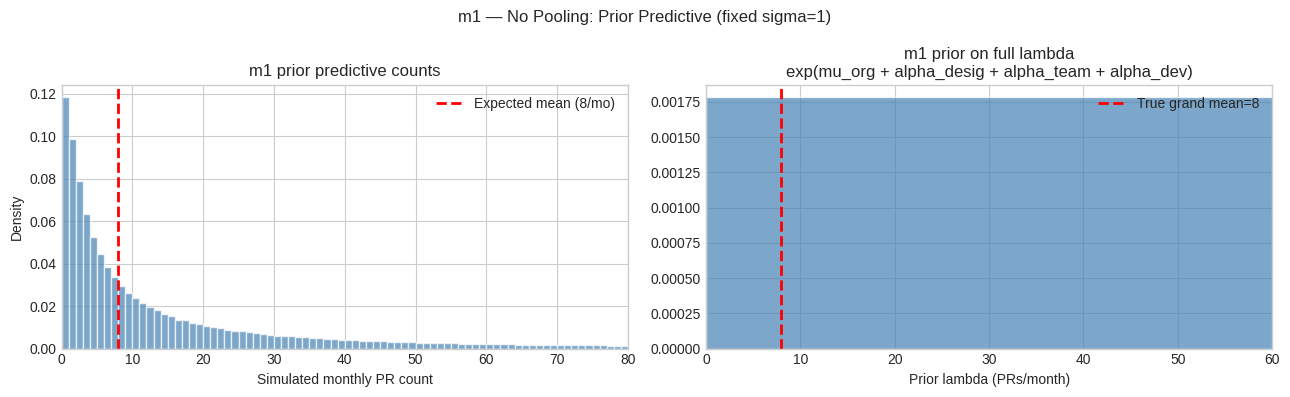

m1 prior lambda: median=8.0, 90% range=[0.4, 146.5] PRs/month


In [12]:
with m1:
    prior_m1 = pm.sample_prior_predictive(samples=500, random_seed=42)

prior_counts_m1 = prior_m1.prior_predictive['obs'].values.flatten()

# Full lambda per observation = exp(mu_org + alpha_desig + alpha_team + alpha_dev)
# 'lam' is already computed as a Deterministic in m1 — use it directly
prior_lam_m1 = prior_m1.prior['lam'].values.flatten()   # shape: (500 * N_OBS,)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(prior_counts_m1,
        bins=range(0, min(int(prior_counts_m1.max())+2, 100)),
        color='steelblue', alpha=0.7, edgecolor='white', density=True)
ax.axvline(8, color='red', linestyle='--', lw=2, label='Expected mean (8/mo)')
ax.set_xlabel("Simulated monthly PR count")
ax.set_ylabel("Density")
ax.set_title("m1 prior predictive counts")
ax.set_xlim(0, 80)
ax.legend()

ax = axes[1]
ax.hist(prior_lam_m1, bins=100, color='steelblue', alpha=0.7,
        edgecolor='white', density=True)
ax.axvline(8, color='red', linestyle='--', lw=2, label='True grand mean=8')
ax.set_xlabel("Prior lambda (PRs/month)")
ax.set_xlim(0, 60)
ax.set_title("m1 prior on full lambda\nexp(mu_org + alpha_desig + alpha_team + alpha_dev)")
ax.legend()

plt.suptitle("m1 — No Pooling: Prior Predictive (fixed sigma=1)", fontsize=12)
plt.tight_layout()
plt.show()

p5, p95 = np.percentile(prior_lam_m1, [5, 95])
print(f"m1 prior lambda: median={np.median(prior_lam_m1):.1f}, "
      f"90% range=[{p5:.1f}, {p95:.1f}] PRs/month")

## Prior Predictive Check — m2

For m2, we also check whether the group-level priors allow sensible
**differences between designations and teams** — not just the overall scale.

Sampling: [mu_org, obs, sigma_desig, sigma_dev, sigma_team, z_desig, z_dev, z_team]


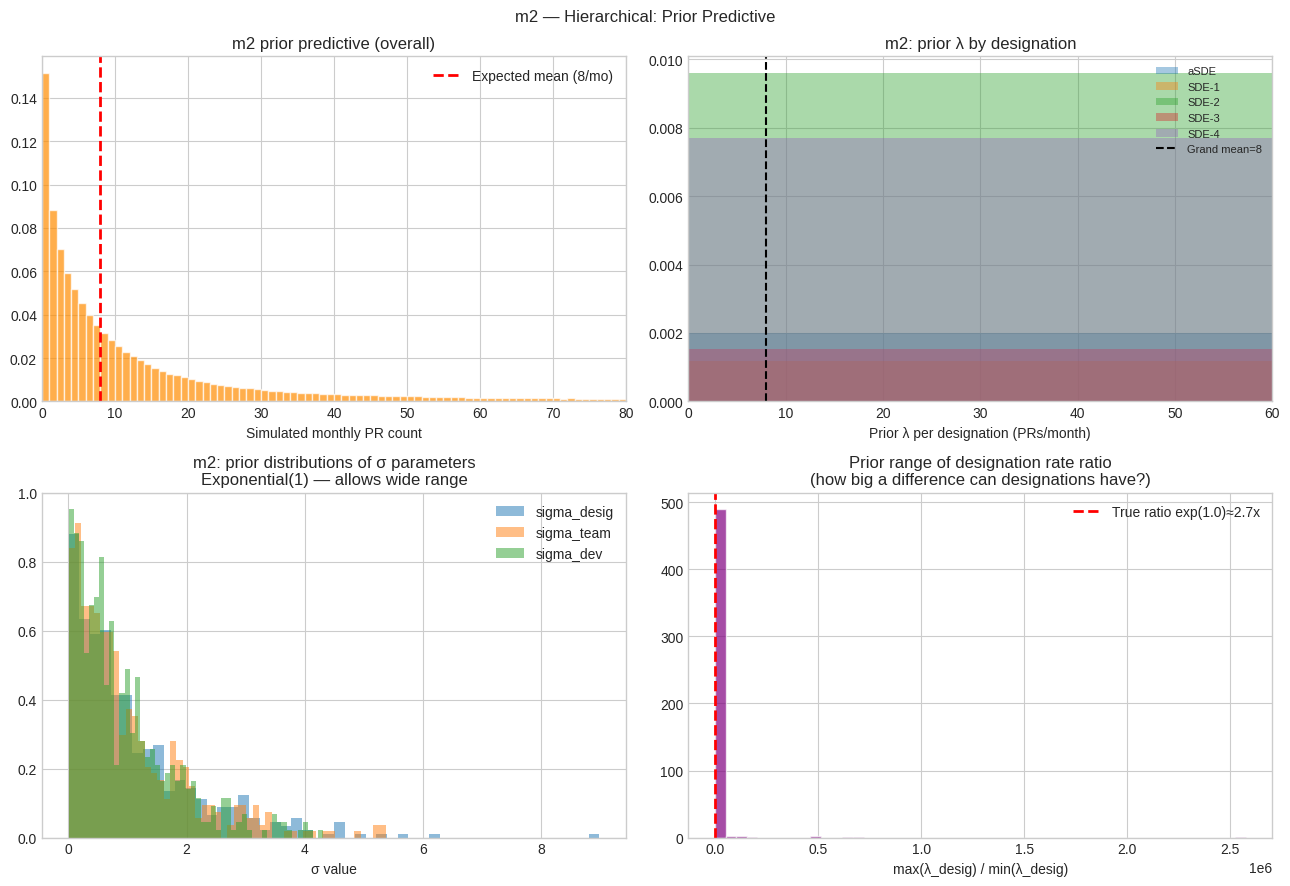

m2 prior predictive counts: 90% range=[0, 372] PRs/month


In [13]:
with m2:
    prior_m2 = pm.sample_prior_predictive(samples=500, random_seed=42)

prior_counts_m2 = prior_m2.prior_predictive['obs'].values.flatten()

# Extract prior designation rates
prior_mu_org  = prior_m2.prior['mu_org'].values.flatten()       # shape: (500,)
prior_delta   = prior_m2.prior['delta'].values.reshape(-1, len(DESIGNATIONS))  # (500, 5)
prior_lam_desig = np.exp(prior_mu_org[:, None] + prior_delta)   # (500, 5)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1: Overall prior predictive counts
ax = axes[0, 0]
ax.hist(prior_counts_m2, bins=range(0, min(prior_counts_m2.max()+2, 120)),
        color='darkorange', alpha=0.7, edgecolor='white', density=True)
ax.axvline(8, color='red', linestyle='--', lw=2, label='Expected mean (8/mo)')
ax.set_xlim(0, 80)
ax.set_xlabel("Simulated monthly PR count")
ax.set_title("m2 prior predictive (overall)")
ax.legend()

# Panel 2: Prior lambda per designation
ax = axes[0, 1]
for i, desig in enumerate(DESIGNATIONS):
    ax.hist(prior_lam_desig[:, i], bins=50, alpha=0.4,
            color=f'C{i}', label=desig, density=True)
ax.axvline(8, color='black', linestyle='--', lw=1.5, label='Grand mean=8')
ax.set_xlim(0, 60)
ax.set_xlabel("Prior λ per designation (PRs/month)")
ax.set_title("m2: prior λ by designation")
ax.legend(fontsize=8)

# Panel 3: Prior sigma distributions
ax = axes[1, 0]
for name, color in [('sigma_desig','C0'), ('sigma_team','C1'), ('sigma_dev','C2')]:
    samples = prior_m2.prior[name].values.flatten()
    ax.hist(samples, bins=50, alpha=0.5, color=color, label=name, density=True)
ax.set_xlabel("σ value")
ax.set_title("m2: prior distributions of σ parameters\nExponential(1) — allows wide range")
ax.legend()

# Panel 4: Prior implied ratio between highest and lowest designation
ax = axes[1, 1]
max_lam = prior_lam_desig.max(axis=1)
min_lam = prior_lam_desig.min(axis=1)
ratio   = max_lam / (min_lam + 1e-6)
ax.hist(ratio, bins=50, color='purple', alpha=0.7, edgecolor='white')
ax.axvline(np.exp(0.3 - (-0.7)), color='red', linestyle='--', lw=2,
           label=f'True ratio exp(1.0)≈{np.exp(1.0):.1f}x')
ax.set_xlabel("max(λ_desig) / min(λ_desig)")
ax.set_title("Prior range of designation rate ratio\n(how big a difference can designations have?)")
ax.legend()

plt.suptitle("m2 — Hierarchical: Prior Predictive", fontsize=12)
plt.tight_layout()
plt.show()

p5, p95 = np.percentile(prior_counts_m2, [5, 95])
print(f"m2 prior predictive counts: 90% range=[{p5:.0f}, {p95:.0f}] PRs/month")

## Compare m1 vs m2 Prior Predictives

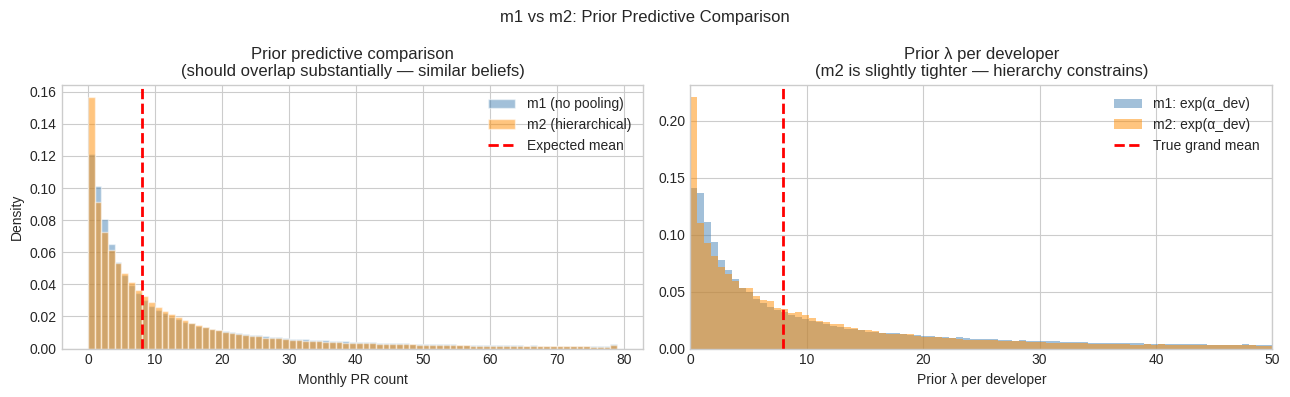

Prior predictive summary:
  m1 counts: mean=37.9, std=205.0, 99th pct=480
  m2 counts: mean=10368.8, std=1388959.1, 99th pct=5989


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: Side-by-side count distributions
ax = axes[0]
bins = range(0, 80)
ax.hist(prior_counts_m1, bins=bins, alpha=0.5, color='steelblue',
        density=True, label='m1 (no pooling)', edgecolor='white')
ax.hist(prior_counts_m2, bins=bins, alpha=0.5, color='darkorange',
        density=True, label='m2 (hierarchical)', edgecolor='white')
ax.axvline(8, color='red', lw=2, linestyle='--', label='Expected mean')
ax.set_xlabel("Monthly PR count")
ax.set_ylabel("Density")
ax.set_title("Prior predictive comparison\n(should overlap substantially — similar beliefs)")
ax.legend()

# Panel 2: Prior λ distributions
ax = axes[1]
prior_lam_m2_all = np.exp(
    prior_m2.prior['alpha'].values.flatten()
)
p_lam_m1 = prior_m1.prior['lam'].values.flatten()

ax.hist(p_lam_m1, bins=100, alpha=0.5, color='steelblue',
        density=True, label='m1: exp(α_dev)', range=(0, 60))
ax.hist(prior_lam_m2_all, bins=100, alpha=0.5, color='darkorange',
        density=True, label='m2: exp(α_dev)', range=(0, 60))
ax.axvline(8, color='red', lw=2, linestyle='--', label='True grand mean')
ax.set_xlabel("Prior λ per developer")
ax.set_xlim(0, 50)
ax.set_title("Prior λ per developer\n(m2 is slightly tighter — hierarchy constrains)")
ax.legend()

plt.suptitle("m1 vs m2: Prior Predictive Comparison", fontsize=12)
plt.tight_layout()
plt.show()

print("Prior predictive summary:")
print(f"  m1 counts: mean={prior_counts_m1.mean():.1f}, "
      f"std={prior_counts_m1.std():.1f}, "
      f"99th pct={np.percentile(prior_counts_m1,99):.0f}")
print(f"  m2 counts: mean={prior_counts_m2.mean():.1f}, "
      f"std={prior_counts_m2.std():.1f}, "
      f"99th pct={np.percentile(prior_counts_m2,99):.0f}")

## Summary

### What we checked
- **Empirical MLE**: raw `total_count / total_exposure` per developer — no model, no priors
- **m1 prior**: `Normal(0, 1)` on log scale for each group — fixed σ, no sharing between groups
- **m2 prior**: same scale, but σ's are learnable — groups share information via hyperpriors

### The core distinction

| | m1 (no pooling) | m2 (partial pooling) |
|--|--|--|
| Group intercepts? | Yes (desig + team + dev) | Yes (desig + team + dev) |
| σ for groups | **Fixed** (hardcoded = 1) | **Estimated** from data |
| Teams learn from each other? | No | Yes — via σ_team |
| New developer prediction | Uses fixed prior only | Uses learned group mean |
| Extreme developers | Stay extreme | Shrunk toward group mean |

### What to expect after fitting
- **m1**: estimates stay close to empirical MLE — fixed σ can't adapt
- **m2**: groups with little data shrink toward the grand mean — adaptive pooling

**Next:** `04_fit_models.ipynb` — fit both models and compare posteriors.